In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
!pip install scipy PyWavelets -q

import requests, io
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scipy.io as iomat
import helpers
from TIMBRE import TIMBRE
from analysis import plot_arm, plot_arm_pinv
import pywt

# --- Load data ---
url = "https://api.figshare.com/v2/articles/24757638"
files = requests.get(url).json()['files']
f = next(x for x in files if x['name'] == 'data04.mat')
data = iomat.loadmat(io.BytesIO(requests.get(f['download_url']).content))

# --- Preprocess ---
LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)
test_inds, train_inds = helpers.test_train(data['lapID'], which_phase=2, n_folds=5, which_fold=0)
wLFPs, U, Xv = helpers.whiten(LFPs, train_inds)
print(f"LFPs shape: {LFPs.shape}, electrodes: {LFPs.shape[1]}")

In [ ]:
m0,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=0)
m3,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)
m6,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

arm_nodes_m0 = helpers.node_arm_map(m0, wLFPs, test_inds, data['lapID'], top_k=1)
arm_nodes_m3 = helpers.node_arm_map(m3, wLFPs, test_inds, data['lapID'], top_k=1)
arm_nodes_m6 = helpers.node_arm_map(m6, wLFPs, test_inds, data['lapID'], top_k=2)

t0 = helpers.get_complex_weights(m0)
t3 = helpers.get_complex_weights(m3, 3)
t6 = helpers.get_complex_weights(m6, 6)

In [3]:
eSpace3 = (np.conj(U.T) / Xv) @ np.conj(t3)
eSpace6 = (np.conj(U.T) / Xv) @ np.conj(t6)
eSpace0 = (np.conj(U.T) / Xv) @ np.conj(t0)

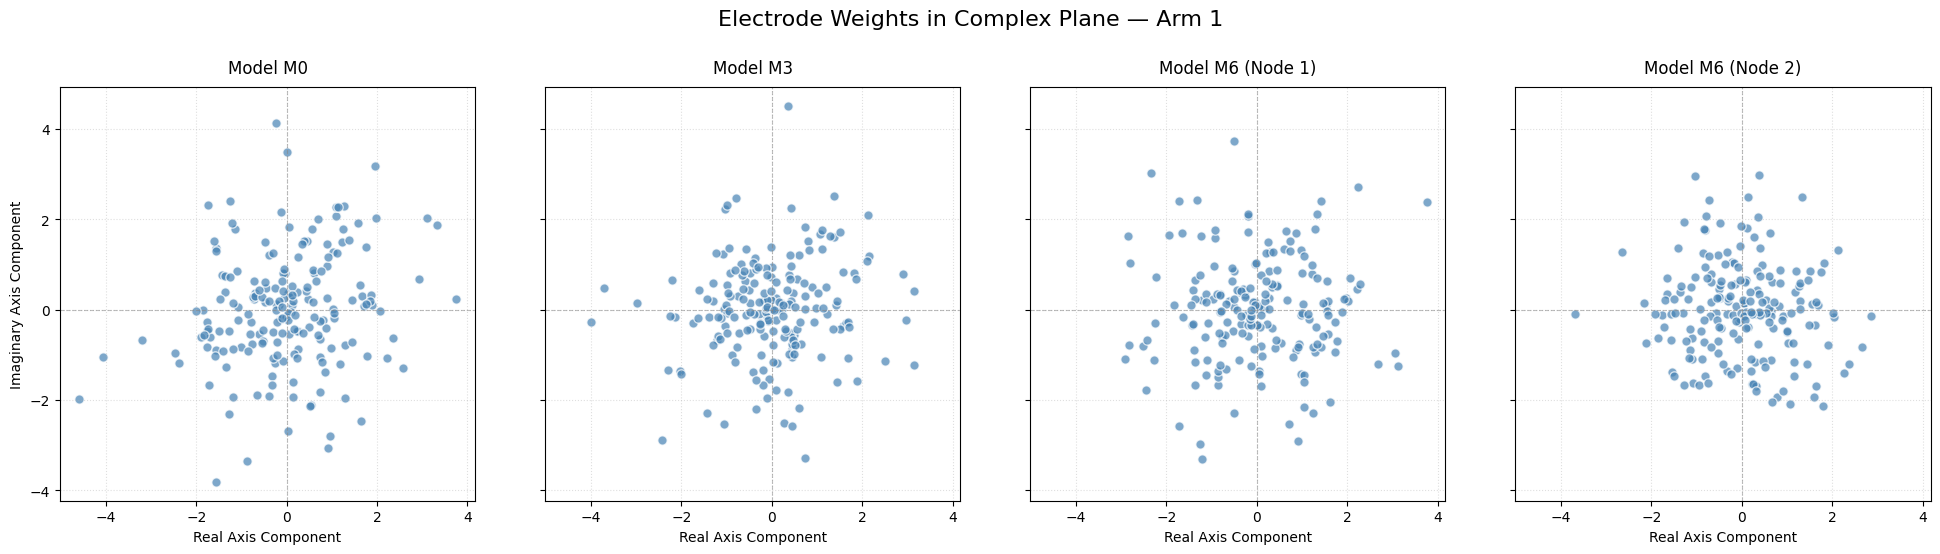

In [31]:
def plot_complex_space(arm_number):
    """
    Plots electrode weights in the complex plane for a specific arm
    across M0, M3, and M6 models.

    PINV Setup
    
    Parameters:
    -----------
    arm_number : int
        The human-readable arm number (1, 2, or 3)
    """
    # Map human-readable arm (1-3) to 0-indexed code arrays
    arm_idx = arm_number - 1
    if arm_idx not in [0, 1, 2]:
        raise ValueError("arm_number must be 1, 2, or 3")
        
    # --- Data Extraction ---
    # M0 (1 node)
    node_m0 = arm_nodes_m0[arm_idx][0]
    f0 = np.linalg.pinv(eSpace0)[node_m0,:]
    
    # M3 (1 node)
    node_m3 = arm_nodes_m3[arm_idx][0]
    f3 = np.linalg.pinv(eSpace3)[node_m3,:]
    
    # M6 (2 nodes mapped to this arm)
    n0, n1 = arm_nodes_m6[arm_idx]
    f6a = np.linalg.pinv(eSpace6)[n0,:]
    f6b = np.linalg.pinv(eSpace6)[n1,:]
    
    # Bundle into a list for clean plotting iteration: (data, panel_title)
    datasets = [
        (f0, "Model M0"),
        (f3, "Model M3"),
        (f6a, "Model M6 (Node 1)"),
        (f6b, "Model M6 (Node 2)")
    ]
    
    # --- Plotting Grid Setup ---
    # sharex and sharey keep scales uniform across models
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle(f'Electrode Weights in Complex Plane — Arm {arm_number}', fontsize=16, y=1.05)
    
    for ax, (f_data, title) in zip(axes, datasets):
        # Draw origin crosshairs
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # Scatter data points
        ax.scatter(
            f_data.real, 
            f_data.imag, 
            color='steelblue', 
            alpha=0.7, 
            edgecolors='w', 
            s=45
        )
        
        # Labels and design tweaks
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel('Real Axis Component', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        # FIX: Changed adjustable from 'datalim' to 'box' 
        # This allows shared axes to safely maintain a 1:1 aspect ratio
        ax.set_aspect('equal', adjustable='box')

    # Only label the left-most Y axis since sharey=True keeps them identical
    axes[0].set_ylabel('Imaginary Axis Component', fontsize=10)
    
    plt.tight_layout()
    plt.show()
plot_complex_space(1)

In [ ]:
plot_arm(0, eSpace0, eSpace3, eSpace6, arm_nodes_m0, arm_nodes_m3, arm_nodes_m6)

In [ ]:
plot_arm_pinv(0, eSpace0, eSpace3, eSpace6, arm_nodes_m0, arm_nodes_m3, arm_nodes_m6)

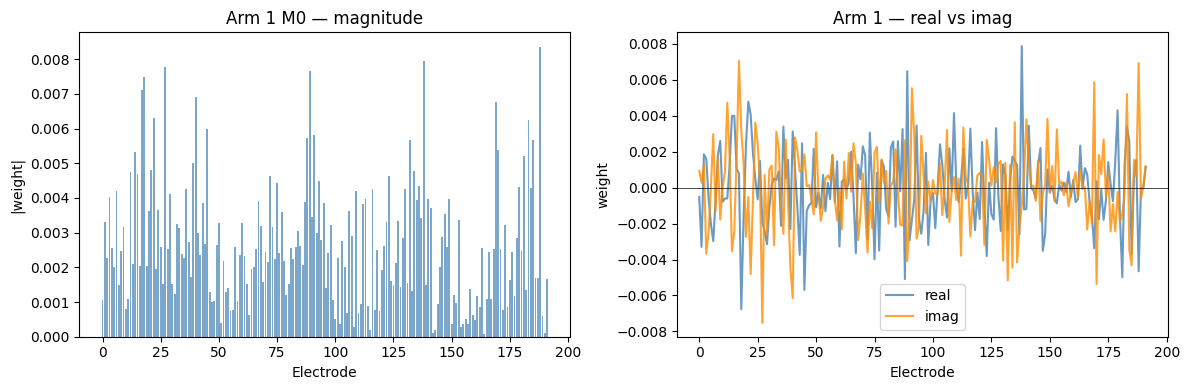

In [6]:
arm_idx = 0
node0   = arm_nodes_m0[arm_idx][0]

f = eSpace0[:, node0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# magnitude
axes[0].bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
axes[0].set_title(f'Arm {arm_idx+1} M0 — magnitude')
axes[0].set_xlabel('Electrode')
axes[0].set_ylabel('|weight|')

# real vs imaginary
axes[1].plot(f.real, color='steelblue', alpha=0.8, label='real')
axes[1].plot(f.imag, color='darkorange', alpha=0.8, label='imag')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(f'Arm {arm_idx+1} — real vs imag')
axes[1].set_xlabel('Electrode')
axes[1].set_ylabel('weight')
axes[1].legend()

plt.tight_layout()
plt.show()

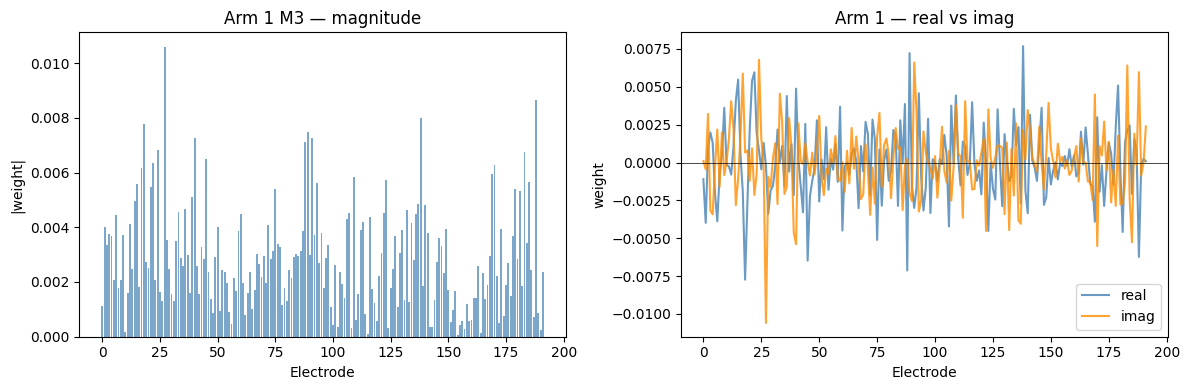

In [7]:
arm_idx = 0
node0   = arm_nodes_m3[arm_idx][0]

f = eSpace3[:, node0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# magnitude
axes[0].bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
axes[0].set_title(f'Arm {arm_idx+1} M3 — magnitude')
axes[0].set_xlabel('Electrode')
axes[0].set_ylabel('|weight|')

# real vs imaginary
axes[1].plot(f.real, color='steelblue', alpha=0.8, label='real')
axes[1].plot(f.imag, color='darkorange', alpha=0.8, label='imag')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(f'Arm {arm_idx+1} — real vs imag')
axes[1].set_xlabel('Electrode')
axes[1].set_ylabel('weight')
axes[1].legend()

plt.tight_layout()
plt.show()

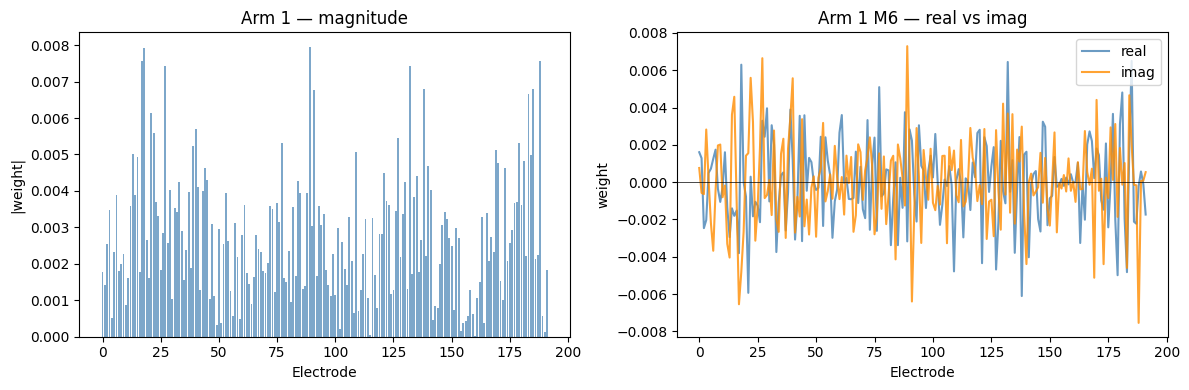

In [8]:
arm_idx = 0
node0   = arm_nodes_m6[arm_idx][0]

f = eSpace6[:, node0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# magnitude
axes[0].bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
axes[0].set_title(f'Arm {arm_idx+1} — magnitude')
axes[0].set_xlabel('Electrode')
axes[0].set_ylabel('|weight|')

# real vs imaginary
axes[1].plot(f.real, color='steelblue', alpha=0.8, label='real')
axes[1].plot(f.imag, color='darkorange', alpha=0.8, label='imag')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title(f'Arm {arm_idx+1} M6 — real vs imag')
axes[1].set_xlabel('Electrode')
axes[1].set_ylabel('weight')
axes[1].legend()

plt.tight_layout()
plt.show()

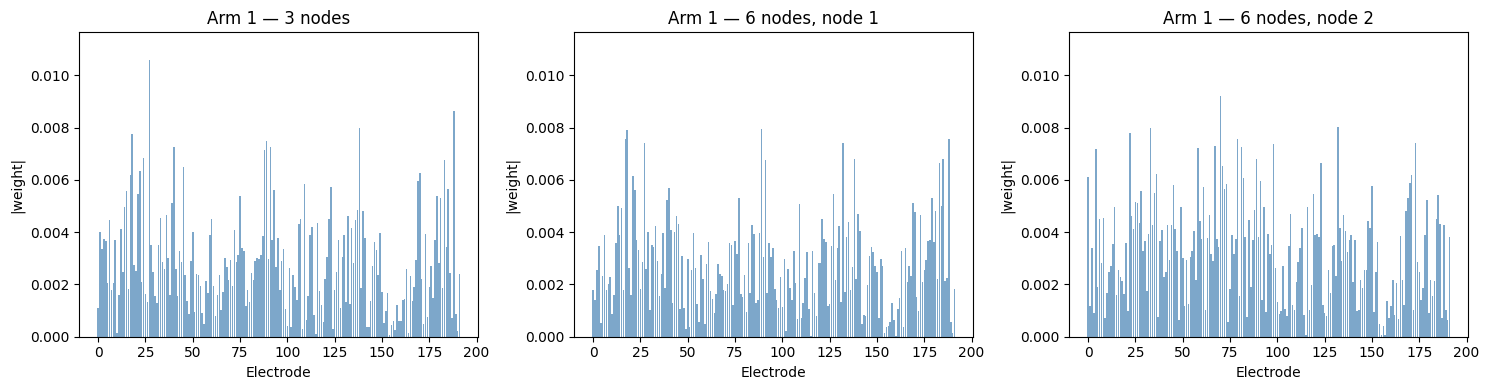

In [5]:
arm_idx = 0  

node3  = arm_nodes_m3[arm_idx][0]
n0, n1 = arm_nodes_m6[arm_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

filters = [
    (eSpace3[:, node3],  f'Arm {arm_idx+1} — 3 nodes'),
    (eSpace6[:, n0],     f'Arm {arm_idx+1} — 6 nodes, node 1'),
    (eSpace6[:, n1],     f'Arm {arm_idx+1} — 6 nodes, node 2'),
]

vmax = max(np.max(np.abs(f)) for f, _ in filters)

for ax, (f, title) in zip(axes, filters):
    ax.bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
    ax.set_ylim(0, vmax * 1.1)
    ax.set_title(title)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('|weight|')

plt.tight_layout()
plt.show()

In [ ]:
#demixing matrix right now
#take mixing matrix but taking psudeo inverse of matrix we are using right now